#2.2 ANALYSIS (SPARK STREAMING PIPELINE)

##Setup

In [ ]:
import os
import subprocess

spark_version = subprocess.run(
    "curl -s https://downloads.apache.org/spark/ | grep -o 'spark-3\\.[0-9]\\+\\.[0-9]\\+' | sort -V | tail -1",
    shell=True, capture_output=True, text=True
).stdout.strip()

spark_release = spark_version
hadoop_version = 'hadoop3'

import os, time
start = time.time()
os.environ['SPARK_RELEASE'] = spark_release
os.environ['HADOOP_VERSION'] = hadoop_version
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = f"/content/{spark_release}-bin-{hadoop_version}"

if True:
    !apt-get install openjdk-8-jdk-headless -qq > /dev/null
    !wget -q http://apache.osuosl.org/spark/${SPARK_RELEASE}/${SPARK_RELEASE}-bin-${HADOOP_VERSION}.tgz
    !tar xf ${SPARK_RELEASE}-bin-${HADOOP_VERSION}.tgz

    !pip install -q findspark
    import findspark
    findspark.init()

import pyspark
print(pyspark.__version__)

!rm -f $SPARK_HOME/jars/hadoop-azure*.jar
!rm -f $SPARK_HOME/jars/azure-storage*.jar

!wget -q https://repo1.maven.org/maven2/org/apache/hadoop/hadoop-azure/3.3.1/hadoop-azure-3.3.1.jar
!wget -q https://repo1.maven.org/maven2/com/microsoft/azure/azure-storage/8.6.6/azure-storage-8.6.6.jar

!mv hadoop-azure-3.3.1.jar $SPARK_HOME/jars/
!mv azure-storage-8.6.6.jar $SPARK_HOME/jars/

import findspark
findspark.init()

from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, TimestampType, DoubleType

spark = SparkSession.builder \
    .appName("ABFS Test") \
    .getOrCreate()

3.5.5


In [ ]:
!pip install azure-storage-blob

##Dataframe creation

In [ ]:
from azure.storage.blob import BlobServiceClient
import os

conn_str = "DefaultEndpointsProtocol=https;AccountName=iesstsabbadbaa;AccountKey=ZT6z+TYSxF0Xdm0vOCRbIpWoBss2BxOU0EcP2UDceddHX7Kyi8gyJvjyWG5THNp2HOprCHmblb2f+AStp8mAGw==;EndpointSuffix=core.windows.net"
container_name = "streamed-data-group1"
folder_prefix = "requests-output/part-00000"

blob_service_client = BlobServiceClient.from_connection_string(conn_str)
container_client = blob_service_client.get_container_client(container_name)

parquet_files = []

for blob in container_client.list_blobs(name_starts_with=folder_prefix):
    if blob.name.endswith(".parquet"):
        print(f"Downloading: {blob.name}")
        local_path = os.path.basename(blob.name)
        blob_client = container_client.get_blob_client(blob)
        with open(local_path, "wb") as f:
            f.write(blob_client.download_blob().readall())
        parquet_files.append(local_path)

df_requests = spark.read.parquet(*parquet_files)
df_requests.show()


Downloading: requests-output/part-00000-00a4c7df-d799-4c4b-a9b2-0c147d6bfa23-c000.snappy.parquet
Downloading: requests-output/part-00000-00e1dc78-25b5-4679-9dd5-9a9ab1a0def0-c000.snappy.parquet
Downloading: requests-output/part-00000-0180100f-ed1f-434a-ba36-18100f74d973-c000.snappy.parquet
Downloading: requests-output/part-00000-027929d7-c0b2-46fa-846d-da9e1bc7a2fd-c000.snappy.parquet
Downloading: requests-output/part-00000-030a902b-8bba-4eeb-b74b-7386ddf19193-c000.snappy.parquet
Downloading: requests-output/part-00000-0406a1e8-bddd-41ea-a6db-9e5533321d0d-c000.snappy.parquet
Downloading: requests-output/part-00000-04f10f27-eb37-43b4-bd72-8c8f2d0e2b32-c000.snappy.parquet
Downloading: requests-output/part-00000-080c6905-8ecf-472b-8494-0c5449e380c3-c000.snappy.parquet
Downloading: requests-output/part-00000-09d97a9b-e73c-4a2a-be07-4e8a6b5d0efa-c000.snappy.parquet
Downloading: requests-output/part-00000-0a3a180a-79d3-440c-9e6f-9e57b95fe71b-c000.snappy.parquet
Downloading: requests-output/p

In [ ]:
from azure.storage.blob import BlobServiceClient
import os

conn_str = "DefaultEndpointsProtocol=https;AccountName=iesstsabbadbaa;AccountKey=ZT6z+TYSxF0Xdm0vOCRbIpWoBss2BxOU0EcP2UDceddHX7Kyi8gyJvjyWG5THNp2HOprCHmblb2f+AStp8mAGw==;EndpointSuffix=core.windows.net"
container_name = "streamed-data-group1"
folder_prefix = "rides-output/part-00000"

blob_service_client = BlobServiceClient.from_connection_string(conn_str)
container_client = blob_service_client.get_container_client(container_name)

parquet_files = []

for blob in container_client.list_blobs(name_starts_with=folder_prefix):
    if blob.name.endswith(".parquet"):
        print(f"Downloading: {blob.name}")
        local_path = os.path.basename(blob.name)
        blob_client = container_client.get_blob_client(blob)
        with open(local_path, "wb") as f:
            f.write(blob_client.download_blob().readall())
        parquet_files.append(local_path)

df_rides = spark.read.parquet(*parquet_files)
df_rides.show()


Downloading: rides-output/part-00000-02fa3c5b-24b7-4771-8ce2-b1ccdc97f6da-c000.snappy.parquet
Downloading: rides-output/part-00000-03116676-0b0e-4b00-8bbb-cffea3321146-c000.snappy.parquet
Downloading: rides-output/part-00000-037128b7-3250-4898-a0db-20b25ccaa265-c000.snappy.parquet
Downloading: rides-output/part-00000-03c14209-f23b-4920-b1b0-8f7690edf523-c000.snappy.parquet
Downloading: rides-output/part-00000-0542d591-d322-44ff-8b60-a6d0b3a2ca66-c000.snappy.parquet
Downloading: rides-output/part-00000-0573cecd-138e-4191-beef-0baeb270fff8-c000.snappy.parquet
Downloading: rides-output/part-00000-05caa1d1-6201-41b0-89a3-06c17ca3bfe5-c000.snappy.parquet
Downloading: rides-output/part-00000-067a9c5e-1962-4c6c-859e-143e98d364be-c000.snappy.parquet
Downloading: rides-output/part-00000-069d7aa6-e7df-48bd-94be-98949132bf07-c000.snappy.parquet
Downloading: rides-output/part-00000-0c41f512-1f4f-4911-bb4f-82ed4d2c68c1-c000.snappy.parquet
Downloading: rides-output/part-00000-0d34b327-e48b-4c78-a7f4

##Basic Analysis

In [ ]:
from pyspark.sql.functions import window
from pyspark.sql.functions import col
from pyspark.sql.functions import from_unixtime
from pyspark.sql.functions import count
from pyspark.sql.functions import avg
from pyspark.sql.functions import window
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df_rides = df_rides.withColumn("pickup_timestamp", from_unixtime(col("pickup_time")))

For the analysis we will apply tumbling windows with a 10 minute duration.

**Total rides that were requested during the time period**

In [ ]:
print("Total rides requested:\n")

df_rides.groupBy(
    window(col("pickup_timestamp"), "10 minutes")
).agg(
    count("*").alias("num_rides")
).orderBy("window").show(truncate=False)

Total rides requested:

+------------------------------------------+---------+
|window                                    |num_rides|
+------------------------------------------+---------+
|{2025-04-01 00:00:00, 2025-04-01 00:10:00}|64       |
|{2025-04-01 00:10:00, 2025-04-01 00:20:00}|62       |
|{2025-04-01 00:20:00, 2025-04-01 00:30:00}|65       |
|{2025-04-01 00:30:00, 2025-04-01 00:40:00}|70       |
|{2025-04-01 00:40:00, 2025-04-01 00:50:00}|67       |
|{2025-04-01 00:50:00, 2025-04-01 01:00:00}|68       |
|{2025-04-01 01:00:00, 2025-04-01 01:10:00}|65       |
|{2025-04-01 01:10:00, 2025-04-01 01:20:00}|76       |
|{2025-04-01 01:20:00, 2025-04-01 01:30:00}|68       |
|{2025-04-01 01:30:00, 2025-04-01 01:40:00}|58       |
|{2025-04-01 01:40:00, 2025-04-01 01:50:00}|66       |
|{2025-04-01 01:50:00, 2025-04-01 02:00:00}|55       |
|{2025-04-01 02:00:00, 2025-04-01 02:10:00}|81       |
|{2025-04-01 02:10:00, 2025-04-01 02:20:00}|69       |
|{2025-04-01 02:20:00, 2025-04-01 02:30:0

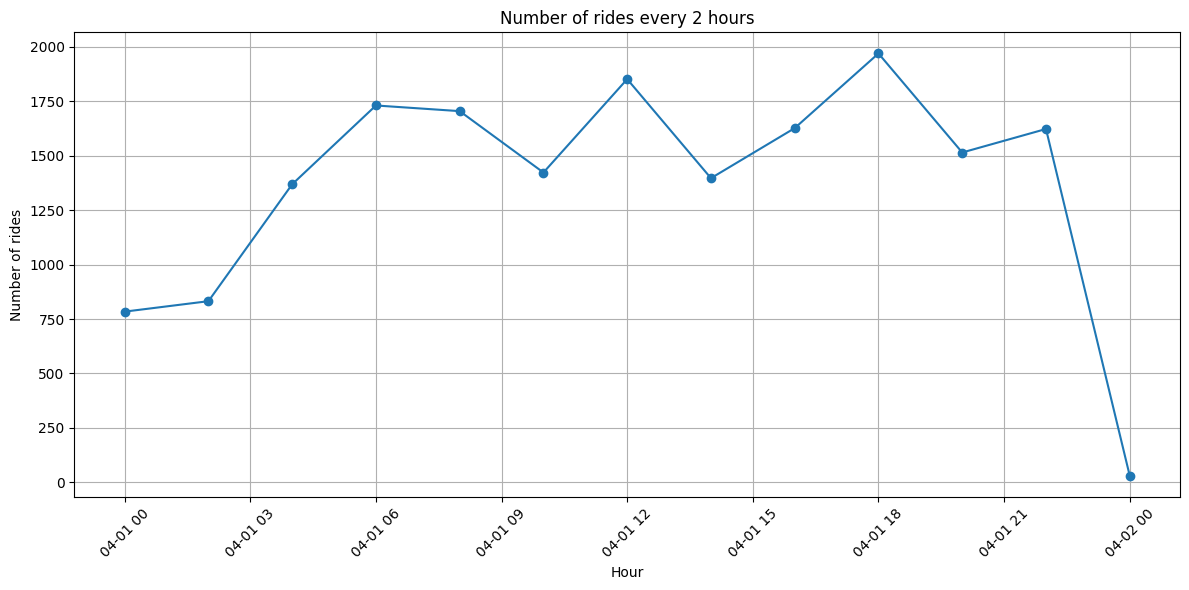

In [ ]:
rides_2hr = df_rides.groupBy(window("pickup_timestamp", "2 hours")).count().orderBy("window") # Changed 'pickup_ts' to 'pickup_timestamp'

rides_pd = rides_2hr.selectExpr("window.start as start", "count").toPandas()
rides_pd['start'] = pd.to_datetime(rides_pd['start'])

plt.figure(figsize=(12, 6))
plt.plot(rides_pd['start'], rides_pd['count'], marker='o')
plt.title("Number of rides every 2 hours")
plt.xlabel("Hour")
plt.ylabel("Number of rides")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

**Total active and completed rides**

In [ ]:
print("Total rides by ride status:\n")

df_rides.withColumn("pickup_timestamp", from_unixtime(col("pickup_time"))) \
    .groupBy(
        window(col("pickup_timestamp"), "10 minutes"),
        col("ride_status")
    ).count() \
    .orderBy("window", "ride_status") \
    .show(truncate=False)

Total rides by ride status:

+------------------------------------------+-----------+-----+
|window                                    |ride_status|count|
+------------------------------------------+-----------+-----+
|{2025-04-01 00:00:00, 2025-04-01 00:10:00}|cancelled  |13   |
|{2025-04-01 00:00:00, 2025-04-01 00:10:00}|completed  |51   |
|{2025-04-01 00:10:00, 2025-04-01 00:20:00}|cancelled  |14   |
|{2025-04-01 00:10:00, 2025-04-01 00:20:00}|completed  |48   |
|{2025-04-01 00:20:00, 2025-04-01 00:30:00}|cancelled  |15   |
|{2025-04-01 00:20:00, 2025-04-01 00:30:00}|completed  |50   |
|{2025-04-01 00:30:00, 2025-04-01 00:40:00}|cancelled  |15   |
|{2025-04-01 00:30:00, 2025-04-01 00:40:00}|completed  |55   |
|{2025-04-01 00:40:00, 2025-04-01 00:50:00}|cancelled  |11   |
|{2025-04-01 00:40:00, 2025-04-01 00:50:00}|completed  |56   |
|{2025-04-01 00:50:00, 2025-04-01 01:00:00}|cancelled  |12   |
|{2025-04-01 00:50:00, 2025-04-01 01:00:00}|completed  |56   |
|{2025-04-01 01:00:00, 202

In [ ]:
df_rides.groupBy("ride_status").count().orderBy(col("count").desc()).show()

+-----------+-----+
|ride_status|count|
+-----------+-----+
|  completed|15451|
|  cancelled| 2407|
+-----------+-----+



**Ride Status Funnel**

 We want a high‑level view of how many ride attempts actually complete versus how many get cancelled, so we can measure our overall conversion efficiency and identify at which step riders drop out.

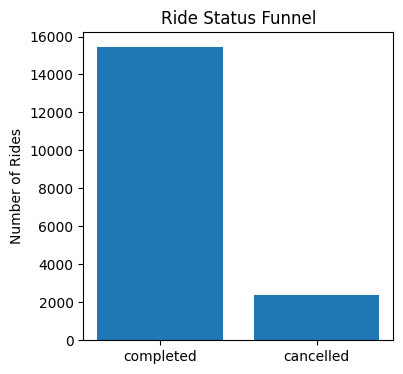

In [ ]:
funnel = df_rides.groupBy("ride_status") \
    .count() \
    .toPandas().set_index("ride_status")

import matplotlib.pyplot as plt
plt.figure(figsize=(4,4))
plt.bar(funnel.index, funnel["count"])
plt.ylabel("Number of Rides")
plt.title("Ride Status Funnel")
plt.show()

**Ride durations and driver response times**

In [ ]:
print("Average ride durations and response times:\n")

df_rides = df_rides.withColumn("driver_response", col("pickup_time") - col("request_time"))

df_rides.groupBy(window(col("pickup_timestamp"), "10 minutes")).agg(
    avg("ride_duration").alias("avg_duration (in seconds)"),
    avg("driver_response").alias("avg_response (in seconds)")
).orderBy("window").show(truncate=False)

Average ride durations and response times:

+------------------------------------------+-------------------------+-------------------------+
|window                                    |avg_duration (in seconds)|avg_response (in seconds)|
+------------------------------------------+-------------------------+-------------------------+
|{2025-04-01 00:00:00, 2025-04-01 00:10:00}|798.890625               |157.90625                |
|{2025-04-01 00:10:00, 2025-04-01 00:20:00}|648.0806451612904        |168.75806451612902       |
|{2025-04-01 00:20:00, 2025-04-01 00:30:00}|744.8923076923077        |175.1076923076923        |
|{2025-04-01 00:30:00, 2025-04-01 00:40:00}|742.9714285714285        |170.31428571428572       |
|{2025-04-01 00:40:00, 2025-04-01 00:50:00}|751.955223880597         |160.77611940298507       |
|{2025-04-01 00:50:00, 2025-04-01 01:00:00}|701.1911764705883        |167.27941176470588       |
|{2025-04-01 01:00:00, 2025-04-01 01:10:00}|753.2461538461539        |153.307692307

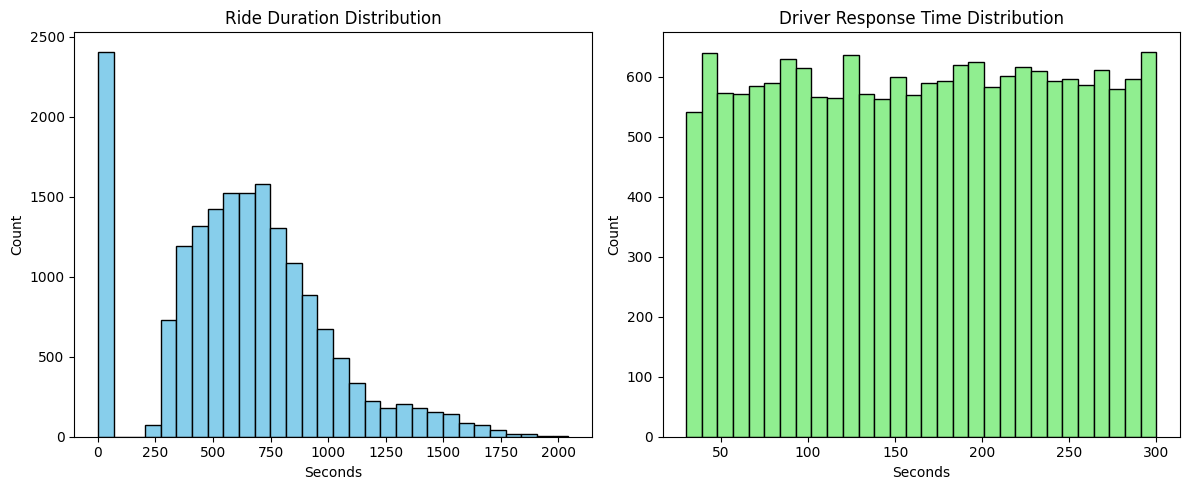

In [ ]:
df_pd = df_rides.select("ride_duration", "driver_response").toPandas()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df_pd["ride_duration"], bins=30, color='skyblue', edgecolor='black')
plt.title("Ride Duration Distribution")
plt.xlabel("Seconds")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
plt.hist(df_pd["driver_response"], bins=30, color='lightgreen', edgecolor='black')
plt.title("Driver Response Time Distribution")
plt.xlabel("Seconds")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

##Intermediate analysis

This helps understand and verify the structure of the data before proceeding with analysis, ensuring that we are working with the correct data types and fields.

In [ ]:
df_rides.printSchema()

print(df_rides.columns)

root
 |-- ride_id: string (nullable = true)
 |-- passenger_id: string (nullable = true)
 |-- driver_id: string (nullable = true)
 |-- ride_status: string (nullable = true)
 |-- request_time: long (nullable = true)
 |-- pickup_time: long (nullable = true)
 |-- dropoff_time: long (nullable = true)
 |-- ride_duration: float (nullable = true)
 |-- pickup_location: string (nullable = true)
 |-- dropoff_location: string (nullable = true)
 |-- distance: float (nullable = true)
 |-- price: float (nullable = true)
 |-- tip: float (nullable = true)
 |-- vehicle_type: string (nullable = true)
 |-- cancellation_reason: string (nullable = true)
 |-- pickup_timestamp: string (nullable = true)
 |-- driver_response: long (nullable = true)

['ride_id', 'passenger_id', 'driver_id', 'ride_status', 'request_time', 'pickup_time', 'dropoff_time', 'ride_duration', 'pickup_location', 'dropoff_location', 'distance', 'price', 'tip', 'vehicle_type', 'cancellation_reason', 'pickup_timestamp', 'driver_response']


In [ ]:
df_rides.describe().show(truncate=False)

+-------+------------------------------------+------------------------------------+------------------------------------+-----------+--------------------+--------------------+--------------------+------------------+---------------+----------------+-----------------+------------------+------------------+------------+-------------------+-------------------+------------------+
|summary|ride_id                             |passenger_id                        |driver_id                           |ride_status|request_time        |pickup_time         |dropoff_time        |ride_duration     |pickup_location|dropoff_location|distance         |price             |tip               |vehicle_type|cancellation_reason|pickup_timestamp   |driver_response   |
+-------+------------------------------------+------------------------------------+------------------------------------+-----------+--------------------+--------------------+--------------------+------------------+---------------+----------------+-

This line is added for early data exploration and validation.

In [ ]:
df_rides.select("ride_status").distinct().show()

+-----------+
|ride_status|
+-----------+
|  completed|
|  cancelled|
+-----------+



**Passenger Session Analysis (15 min gap)**

To capture each rider’s activity bursts—grouping their ride events into “sessions” separated by at least 15 minutes of inactivity—so we can identify highly engaged users or those with long wait times.

In [ ]:
from pyspark.sql.functions import from_unixtime, session_window, col, count, avg, countDistinct

df_rides = df_rides.withColumn(
    "pickup_ts",
    from_unixtime(col("pickup_time")).cast("timestamp")
)

passenger_sessions = df_rides.groupBy(
    session_window("pickup_ts", "15 minutes"),
    col("passenger_id")
).agg(
    count("*").alias("events_per_session"),
    avg("ride_duration").alias("avg_ride_duration_sec"),
    avg("driver_response").alias("avg_driver_response_sec"),
    countDistinct("ride_id").alias("unique_rides")
).orderBy("session_window")

print("=== Passenger Sessions (15 min gap) ===")
passenger_sessions.show(truncate=False)

=== Passenger Sessions (15 min gap) ===
+------------------------------------------+------------------------------------+------------------+---------------------+-----------------------+------------+
|session_window                            |passenger_id                        |events_per_session|avg_ride_duration_sec|avg_driver_response_sec|unique_rides|
+------------------------------------------+------------------------------------+------------------+---------------------+-----------------------+------------+
|{2025-04-01 00:00:49, 2025-04-01 00:15:49}|9e891450-1a0f-4ca7-b5c0-fd2f80aad72a|1                 |0.0                  |49.0                   |1           |
|{2025-04-01 00:00:52, 2025-04-01 00:15:52}|1031701b-7260-4c99-aa8c-e21f23c49439|1                 |1477.0               |52.0                   |1           |
|{2025-04-01 00:01:39, 2025-04-01 00:16:39}|931a2381-9ab7-4946-89be-0c3d61934042|1                 |1014.0               |99.0                   |1           |


 .

**Demand vs Supply Matching (10 min Tumbling Windows)**

We group rides into 10‑minute intervals and count how many unique passengers requested trips (demand) versus how many unique drivers were active (supply). By calculating the supply‑to‑demand ratio, we can immediately spot periods where driver availability falls short or exceeds rider needs.

In [ ]:
from pyspark.sql.functions import window, countDistinct

demand_supply = df_rides.groupBy(
    window("pickup_ts", "10 minutes")
).agg(
    countDistinct("passenger_id").alias("demand"),
    countDistinct("driver_id").alias("supply")
).withColumn(
    "supply_demand_ratio",
    col("supply") / col("demand")
).orderBy("window")

print("=== Demand vs Supply (10 min) ===")
demand_supply.show(truncate=False)

=== Demand vs Supply (10 min) ===
+------------------------------------------+------+------+-------------------+
|window                                    |demand|supply|supply_demand_ratio|
+------------------------------------------+------+------+-------------------+
|{2025-04-01 00:00:00, 2025-04-01 00:10:00}|64    |64    |1.0                |
|{2025-04-01 00:10:00, 2025-04-01 00:20:00}|62    |62    |1.0                |
|{2025-04-01 00:20:00, 2025-04-01 00:30:00}|65    |65    |1.0                |
|{2025-04-01 00:30:00, 2025-04-01 00:40:00}|70    |70    |1.0                |
|{2025-04-01 00:40:00, 2025-04-01 00:50:00}|67    |67    |1.0                |
|{2025-04-01 00:50:00, 2025-04-01 01:00:00}|68    |68    |1.0                |
|{2025-04-01 01:00:00, 2025-04-01 01:10:00}|65    |65    |1.0                |
|{2025-04-01 01:10:00, 2025-04-01 01:20:00}|76    |76    |1.0                |
|{2025-04-01 01:20:00, 2025-04-01 01:30:00}|68    |68    |1.0                |
|{2025-04-01 01:30

.

**Cancellation Trends (10 min Windows)**

We compute the share of rides that get cancelled in each 10‑minute interval so we can quickly spot any sudden spikes in rider or driver drop‑offs and investigate root causes (e.g., app errors, traffic jams, weather).

In [ ]:
from pyspark.sql.functions import count, when

cancellation = df_rides.groupBy(
    window("pickup_ts", "10 minutes")
).agg(
    count("*").alias("total_rides"),
    count(when(col("ride_status") == "cancelled", True)).alias("num_cancelled")
).withColumn(
    "cancellation_rate",
    col("num_cancelled") / col("total_rides")
).orderBy("window")

print("=== Cancellation Rates (10 min) ===")
cancellation.show(truncate=False)

=== Cancellation Rates (10 min) ===
+------------------------------------------+-----------+-------------+-------------------+
|window                                    |total_rides|num_cancelled|cancellation_rate  |
+------------------------------------------+-----------+-------------+-------------------+
|{2025-04-01 00:00:00, 2025-04-01 00:10:00}|64         |13           |0.203125           |
|{2025-04-01 00:10:00, 2025-04-01 00:20:00}|62         |14           |0.22580645161290322|
|{2025-04-01 00:20:00, 2025-04-01 00:30:00}|65         |15           |0.23076923076923078|
|{2025-04-01 00:30:00, 2025-04-01 00:40:00}|70         |15           |0.21428571428571427|
|{2025-04-01 00:40:00, 2025-04-01 00:50:00}|67         |11           |0.16417910447761194|
|{2025-04-01 00:50:00, 2025-04-01 01:00:00}|68         |12           |0.17647058823529413|
|{2025-04-01 01:00:00, 2025-04-01 01:10:00}|65         |14           |0.2153846153846154 |
|{2025-04-01 01:10:00, 2025-04-01 01:20:00}|76        

**Hour‑of‑Day Demand & Cancellation Patterns**

We want to understand when our service is most in‑demand and when cancellations peak throughout the 24‑hour cycle, so we can staff drivers and adjust incentives dynamically.

In [ ]:
from pyspark.sql.functions import hour, count, when, col

hourly = df_rides.withColumn("hour", hour("pickup_ts")) \
    .groupBy("hour") \
    .agg(
        count("*").alias("total_rides"),
        count(when(col("ride_status")=="cancelled", True)).alias("cancelled_rides")
    ) \
    .withColumn("cancel_rate", col("cancelled_rides")/col("total_rides")) \
    .orderBy("hour")

hourly.show()


+----+-----------+---------------+-------------------+
|hour|total_rides|cancelled_rides|        cancel_rate|
+----+-----------+---------------+-------------------+
|   0|        426|             86|0.20187793427230047|
|   1|        388|             93|0.23969072164948454|
|   2|        441|             92|0.20861678004535147|
|   3|        391|             75| 0.1918158567774936|
|   4|        682|             80|0.11730205278592376|
|   5|        687|             75| 0.1091703056768559|
|   6|        757|            107|0.14134742404227213|
|   7|        974|            135|0.13860369609856263|
|   8|        989|            118|0.11931243680485339|
|   9|        716|             92|0.12849162011173185|
|  10|        700|            103|0.14714285714285713|
|  11|        723|             87|0.12033195020746888|
|  12|        884|            115|0.13009049773755657|
|  13|        968|            123|0.12706611570247933|
|  14|        699|             85|0.12160228898426323|
|  15|    

**Cancellation Ratio per Hour (Plot)**

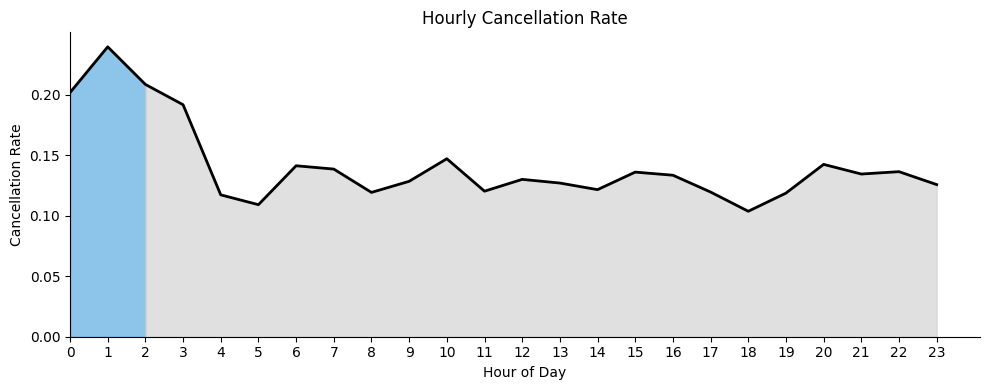

In [ ]:
from pyspark.sql.functions import hour, count, when, col
import matplotlib.pyplot as plt

hourly_cancel = (
    df_rides
      .withColumn("hour", hour(col("pickup_ts")))
      .groupBy("hour")
      .agg(
          (count(when(col("ride_status") == "cancelled", True))
           / count("*")
          ).alias("cancellation_rate")
      )
      .orderBy("hour")
)

pdf = hourly_cancel.toPandas()
x = pdf["hour"]
y = pdf["cancellation_rate"]

fig, ax = plt.subplots(figsize=(10, 4))

ax.fill_between(x, y, where=(x <= 2), color="#5DADE2", alpha=0.7)
ax.fill_between(x, y, where=(x >= 2), color="lightgrey", alpha=0.7)

ax.plot(x, y, color="black", linewidth=2)

ax.spines["bottom"].set_position(("data", 0))
ax.spines["left"].set_position(("data", 0))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

ax.set_xticks(range(0, 24))
ax.set_yticks([i * 0.05 for i in range(0, int(y.max() * 20) + 1)])

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Cancellation Rate")
ax.set_title("Hourly Cancellation Rate")

plt.tight_layout()
plt.show()


Cancellations peak overnight in the early hours, then quickly ease off by dawn and hold at a fairly steady, lower level throughout the rest of the day.

**Cancellation Reason Breakdown (15 min Windows)**

We want to pinpoint why rides are being cancelled—distinguishing between rider‑initiated cancellations, driver‑initiated cancellations, or other causes—so we can target fixes (e.g., improve driver reliability or rider UX).

In [ ]:
from pyspark.sql.functions import window, col, count

cancel_reasons = df_rides.filter(col("ride_status")=="cancelled") \
  .groupBy(window("pickup_ts","15 minutes"), col("cancellation_reason")) \
  .count() \
  .orderBy("window","count", ascending=False)

cancel_reasons.show(truncate=False)


+------------------------------------------+-------------------+-----+
|window                                    |cancellation_reason|count|
+------------------------------------------+-------------------+-----+
|{2025-04-02 00:00:00, 2025-04-02 00:15:00}|Passenger_cancelled|3    |
|{2025-04-02 00:00:00, 2025-04-02 00:15:00}|Other              |2    |
|{2025-04-02 00:00:00, 2025-04-02 00:15:00}|Driver_cancelled   |1    |
|{2025-04-01 23:45:00, 2025-04-02 00:00:00}|Passenger_cancelled|8    |
|{2025-04-01 23:45:00, 2025-04-02 00:00:00}|Other              |7    |
|{2025-04-01 23:45:00, 2025-04-02 00:00:00}|Driver_cancelled   |7    |
|{2025-04-01 23:30:00, 2025-04-01 23:45:00}|Passenger_cancelled|10   |
|{2025-04-01 23:30:00, 2025-04-01 23:45:00}|Driver_cancelled   |9    |
|{2025-04-01 23:30:00, 2025-04-01 23:45:00}|Other              |9    |
|{2025-04-01 23:15:00, 2025-04-01 23:30:00}|Other              |15   |
|{2025-04-01 23:15:00, 2025-04-01 23:30:00}|Driver_cancelled   |7    |
|{2025

**Customer Satisfaction Proxy (10 min Tip Analysis)**

We track tipping behavior on completed rides—calculating the average tip amount and the share of trips that received any tip—to infer rider satisfaction when explicit ratings aren’t available.

In [ ]:
from pyspark.sql.functions import avg, count, when

satisfaction = df_rides.filter(col("ride_status") == "completed") \
    .groupBy(window("pickup_ts", "10 minutes")) \
    .agg(
        avg("tip").alias("avg_tip_amount"),
        (count(when(col("tip") > 0, True)) / count("*")).alias("tip_inclusion_rate"),
        count("*").alias("num_completed")
    ) \
    .orderBy("window")

print("=== Customer Satisfaction Proxy (10 min) ===")
satisfaction.show(truncate=False)

=== Customer Satisfaction Proxy (10 min) ===
+------------------------------------------+------------------+-------------------+-------------+
|window                                    |avg_tip_amount    |tip_inclusion_rate |num_completed|
+------------------------------------------+------------------+-------------------+-------------+
|{2025-04-01 00:00:00, 2025-04-01 00:10:00}|1.461568627871719 |0.47058823529411764|51           |
|{2025-04-01 00:10:00, 2025-04-01 00:20:00}|1.71374998614192  |0.4583333333333333 |48           |
|{2025-04-01 00:20:00, 2025-04-01 00:30:00}|1.7784000039100647|0.4                |50           |
|{2025-04-01 00:30:00, 2025-04-01 00:40:00}|1.8005454616113143|0.4909090909090909 |55           |
|{2025-04-01 00:40:00, 2025-04-01 00:50:00}|1.3930357098579407|0.42857142857142855|56           |
|{2025-04-01 00:50:00, 2025-04-01 01:00:00}|2.6601785788578645|0.6428571428571429 |56           |
|{2025-04-01 01:00:00, 2025-04-01 01:10:00}|1.727843154294818 |0.52941176

.

**Tip Behavior by Vehicle Type**

 We compare tipping patterns across “shared”, “standard”, and “premium” rides to understand which service tiers deliver the best rider satisfaction—and where we might adjust incentives or pricing.

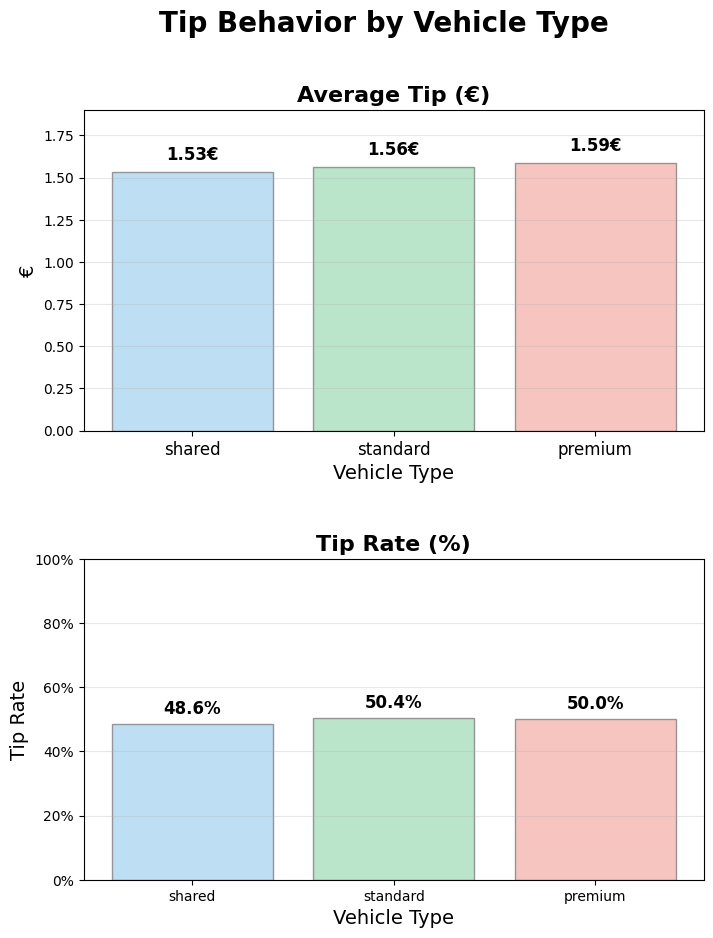

In [ ]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

tips_pd = (
    df_rides
      .filter(F.col("ride_status") == "completed")
      .groupBy("vehicle_type")
      .agg(
          F.avg("tip").alias("avg_tip"),
          (F.sum(F.when(F.col("tip") > 0, 1).otherwise(0)) / F.count("*"))
            .alias("tip_rate")
      )
      .toPandas()
      .set_index("vehicle_type")
      .loc[["shared","standard","premium"]]
      .reset_index()
)

color_map = {"shared":"#AED6F1","standard":"#A9DFBF","premium":"#F5B7B1"}
colors = [color_map[v] for v in tips_pd["vehicle_type"]]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10), sharex=True)

fig.suptitle("Tip Behavior by Vehicle Type", fontsize=20, fontweight="bold")

bars1 = ax1.bar(
    tips_pd["vehicle_type"],
    tips_pd["avg_tip"],
    color=colors,
    edgecolor="gray",
    alpha=0.8
)
ax1.set_title("Average Tip (€)", fontsize=16, fontweight="bold")
ax1.set_ylabel("€", fontsize=14)
ax1.set_ylim(0, tips_pd["avg_tip"].max() * 1.2)
ax1.grid(axis="y", alpha=0.3)

ax1.tick_params(axis="x", labelbottom=True)
ax1.set_xticks(range(len(tips_pd)))
ax1.set_xticklabels(tips_pd["vehicle_type"], fontsize=12)
ax1.set_xlabel("Vehicle Type", fontsize=14)

for bar, avg in zip(bars1, tips_pd["avg_tip"]):
    x = bar.get_x() + bar.get_width()/2
    h = bar.get_height()
    ax1.text(
        x, h + 0.05,
        f"{avg:.2f}€",
        ha="center", va="bottom",
        fontsize=12, fontweight="bold"
    )

bars2 = ax2.bar(
    tips_pd["vehicle_type"],
    tips_pd["tip_rate"],
    color=colors,
    edgecolor="gray",
    alpha=0.8
)
ax2.set_title("Tip Rate (%)", fontsize=16, fontweight="bold")
ax2.set_ylabel("Tip Rate", fontsize=14)
ax2.set_ylim(0, 1)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax2.grid(axis="y", alpha=0.3)

for bar, rate in zip(bars2, tips_pd["tip_rate"]):
    x = bar.get_x() + bar.get_width()/2
    h = bar.get_height()
    ax2.text(
        x, h + 0.02,
        f"{rate:.1%}",
        ha="center", va="bottom",
        fontsize=12, fontweight="bold"
    )

ax2.set_xlabel("Vehicle Type", fontsize=14)
fig.subplots_adjust(top=0.88, hspace=0.4)

plt.show()

This tells us that riders in our mid‑ and high‑end tiers tip more often and tip slightly more—confirming that service quality and perceived value are higher in those classes. We can use this insight to reward premium drivers, refine shared‑ride incentives, or tailor promotions to boost tip rates.

**Revenue & Tip per Zone**

 We want to identify the most lucrative pickup areas—where average fare and tip revenue are highest—so we can tailor pricing, promotions, or driver incentives to maximize ROI.

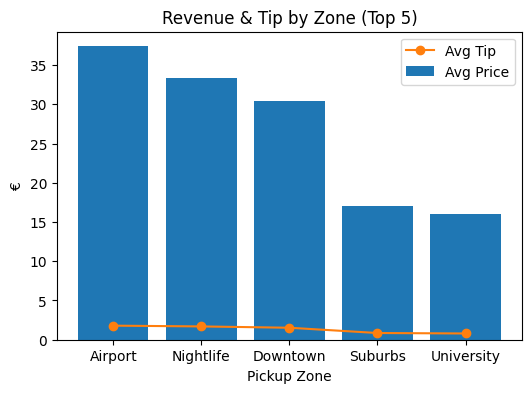

In [ ]:
from pyspark.sql.functions import avg

revenue = df_rides.groupBy("pickup_location") \
    .agg(
      avg("price").alias("avg_price"),
      avg("tip").alias("avg_tip"),
      count("*").alias("num_rides")
    ) \
    .orderBy(col("avg_price").desc())

rev_pd = revenue.limit(5).toPandas()

import matplotlib.pyplot as plt
x = rev_pd["pickup_location"]
plt.figure(figsize=(6,4))
plt.bar(x, rev_pd["avg_price"], label="Avg Price")
plt.plot(x, rev_pd["avg_tip"], marker="o", color="C1", label="Avg Tip")
plt.xlabel("Pickup Zone")
plt.ylabel("€")
plt.title("Revenue & Tip by Zone (Top 5)")
plt.legend()
plt.show()

This tells us that while Airport and Nightlife generate the most gross revenue, tip behavior is relatively flat across zones—suggesting we could boost driver earnings by offering tip incentives in high‑fare areas.

.

**Spatio‑Temporal Demand Heatmap by Zone**

 We need to know where and when our service is most in demand so we can proactively position drivers in the right zones at the right hours.

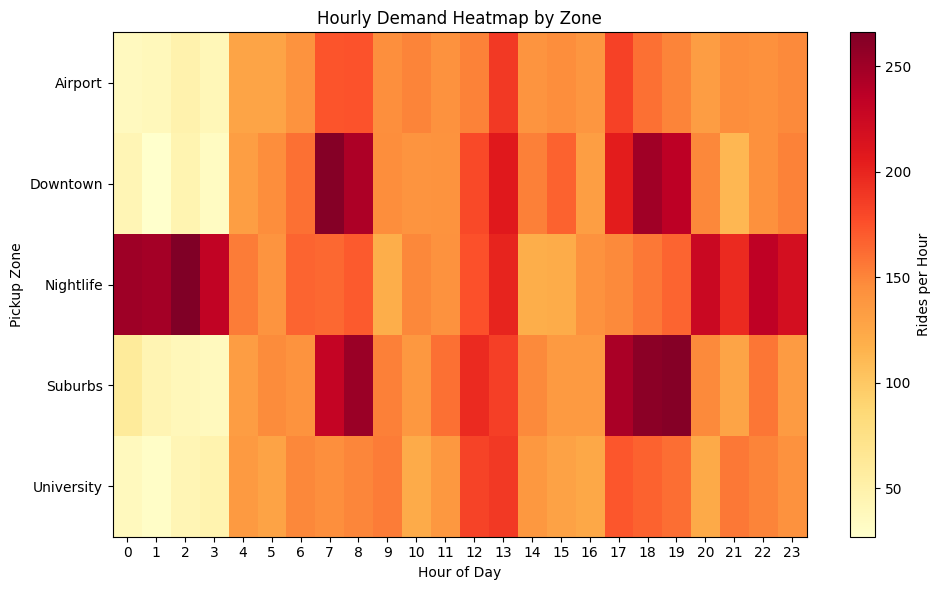

In [ ]:
from pyspark.sql.functions import hour

heat_df = df_rides.withColumn("hour", hour("pickup_ts")) \
    .groupBy("pickup_location") \
    .pivot("hour", list(range(0,24))) \
    .count() \
    .na.fill(0) \
    .orderBy("pickup_location")

heat_pd = heat_df.toPandas().set_index("pickup_location")
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.imshow(heat_pd, aspect="auto", cmap="YlOrRd")
plt.colorbar(label="Rides per Hour")
plt.xticks(range(24), range(24))
plt.yticks(range(len(heat_pd.index)), heat_pd.index)
plt.xlabel("Hour of Day")
plt.ylabel("Pickup Zone")
plt.title("Hourly Demand Heatmap by Zone")
plt.tight_layout()
plt.show()

Nightlife demand peaks consistently through the early hours, Downtown shows a sharp surge during the morning commute, and Suburbs remain quieter midday—guiding dynamic driver repositioning and incentive allocation.

.

##Advanced analysis

We will first look for anomalies in the data. For instance, we'll flag rides with a duration inferior to 60 seconds or greater than 7200 seconds (2 hours).

In [ ]:
anomalies_df = df_rides.filter(
    (col("ride_duration") < 60) | (col("ride_duration") > 7200)
)

anomalies_df.select(
    "ride_id", "ride_duration", "pickup_location", "dropoff_location", "ride_status"
).show(truncate=False)

+------------------------------------+-------------+---------------+----------------+-----------+
|ride_id                             |ride_duration|pickup_location|dropoff_location|ride_status|
+------------------------------------+-------------+---------------+----------------+-----------+
|16e820c6-74b0-465b-8eb2-af50a56e0f1e|0.0          |Nightlife      |Suburbs         |cancelled  |
|c1fded70-8fda-4843-84c8-1d2878c0da64|0.0          |Downtown       |Downtown        |cancelled  |
|37587a34-be3f-4592-b9f3-0446234a96b5|0.0          |University     |Suburbs         |cancelled  |
|687583e1-7716-499e-8d10-cef50ca6afdf|0.0          |Nightlife      |University      |cancelled  |
|b69dd505-9cef-47a2-8dfb-ac36d6c331f0|0.0          |Downtown       |Airport         |cancelled  |
|c1c48d85-1ebf-4338-9894-6292e2ef49fd|0.0          |Nightlife      |Airport         |cancelled  |
|e92934ae-a9ab-4a46-aaea-60d52592da71|0.0          |University     |Nightlife       |cancelled  |
|b1fc2e93-c5fb-4192-

In [ ]:
num_outliers = df_rides.filter(
    (col("ride_duration") < 60) | (col("ride_duration") > 7200)
).count()

print(f"Number of ride duration outliers: {num_outliers}")

Number of ride duration outliers: 2407


There are a total of 2407 rides that can be classified as outliers; out of which several have a duration of 0.0 seconds. However, these are rides that were cancelled. Let's see whether there were any that were completed and fall within these intervals.


In [ ]:
anomalies_df.groupBy("ride_status").count().orderBy("count", ascending=False).show()

+-----------+-----+
|ride_status|count|
+-----------+-----+
|  cancelled| 2407|
+-----------+-----+



All of the rides that lasted for 0.0 seconds were cancelled, so we cannot classify this as an anomaly.

We will now develop a comprehensive table of possible anomalies such as:
- Long response
- Rides that were completed without making a payment
- Rides in which the tip was greater than the price of the ride
- Rides booked with a coinciding pick up and drop off point

In [ ]:
from pyspark.sql.functions import col, lit, when

df_anomalies = df_rides.withColumn("anomaly_duration", (col("ride_duration") < 60) | (col("ride_duration") > 7200)) \
    .withColumn("anomaly_negative_values",
                (col("price") < 0) | (col("tip") < 0) | (col("distance") < 0) | (col("ride_duration") < 0)) \
    .withColumn("anomaly_long_response", col("driver_response") > 1800) \
    .withColumn("anomaly_zero_price_completed", (col("ride_status") == "completed") & (col("price") == 0)) \
    .withColumn("anomaly_tip_gt_price", col("tip") > col("price")) \
    .withColumn("anomaly_same_location", col("pickup_location") == col("dropoff_location"))

final_anomalies_df = df_anomalies.filter(
    col("anomaly_duration") |
    col("anomaly_negative_values") |
    col("anomaly_long_response") |
    col("anomaly_zero_price_completed") |
    col("anomaly_tip_gt_price") |
    col("anomaly_same_location")
)

final_anomalies_df.select(
    "ride_id", "ride_status", "ride_duration", "driver_response", "distance", "price", "tip",
    "pickup_location", "dropoff_location",
    "anomaly_duration", "anomaly_negative_values", "anomaly_long_response",
    "anomaly_zero_price_completed", "anomaly_tip_gt_price",
    "anomaly_same_location"
).show(truncate=False)

+------------------------------------+-----------+-------------+---------------+--------+-----+----+---------------+----------------+----------------+-----------------------+---------------------+----------------------------+--------------------+---------------------+
|ride_id                             |ride_status|ride_duration|driver_response|distance|price|tip |pickup_location|dropoff_location|anomaly_duration|anomaly_negative_values|anomaly_long_response|anomaly_zero_price_completed|anomaly_tip_gt_price|anomaly_same_location|
+------------------------------------+-----------+-------------+---------------+--------+-----+----+---------------+----------------+----------------+-----------------------+---------------------+----------------------------+--------------------+---------------------+
|16e820c6-74b0-465b-8eb2-af50a56e0f1e|cancelled  |0.0          |176            |16.7    |0.0  |0.0 |Nightlife      |Suburbs         |true            |false                  |false              

In [ ]:
from pyspark.sql import functions as F

df_anomalies.select(
    F.sum(col("anomaly_duration").cast("int")).alias("duration_outliers"),
    F.sum(col("anomaly_negative_values").cast("int")).alias("negative_values"),
    F.sum(col("anomaly_long_response").cast("int")).alias("long_response_time"),
    F.sum(col("anomaly_zero_price_completed").cast("int")).alias("zero_price_completed"),
    F.sum(col("anomaly_tip_gt_price").cast("int")).alias("tip_greater_than_price"),
    F.sum(col("anomaly_same_location").cast("int")).alias("same_pickup_dropoff")
).show()

+-----------------+---------------+------------------+--------------------+----------------------+-------------------+
|duration_outliers|negative_values|long_response_time|zero_price_completed|tip_greater_than_price|same_pickup_dropoff|
+-----------------+---------------+------------------+--------------------+----------------------+-------------------+
|             2407|              0|                 0|                   0|                     0|               3565|
+-----------------+---------------+------------------+--------------------+----------------------+-------------------+



In [ ]:
from pyspark.sql.functions import col, sum as _sum  # Import PySpark's sum

anomaly_counts = df_anomalies.select(
    _sum(col("anomaly_duration").cast("int")).alias("Duration Outliers"),
    _sum(col("anomaly_negative_values").cast("int")).alias("Negative Values"),
    _sum(col("anomaly_long_response").cast("int")).alias("Long Driver Response"),
    _sum(col("anomaly_zero_price_completed").cast("int")).alias("Zero Price on Completed"),
    _sum(col("anomaly_tip_gt_price").cast("int")).alias("Tip > Price"),
    _sum(col("anomaly_same_location").cast("int")).alias("Same Pickup & Dropoff")
).toPandas().T.reset_index()

anomaly_counts.columns = ["Anomaly Type", "Count"]

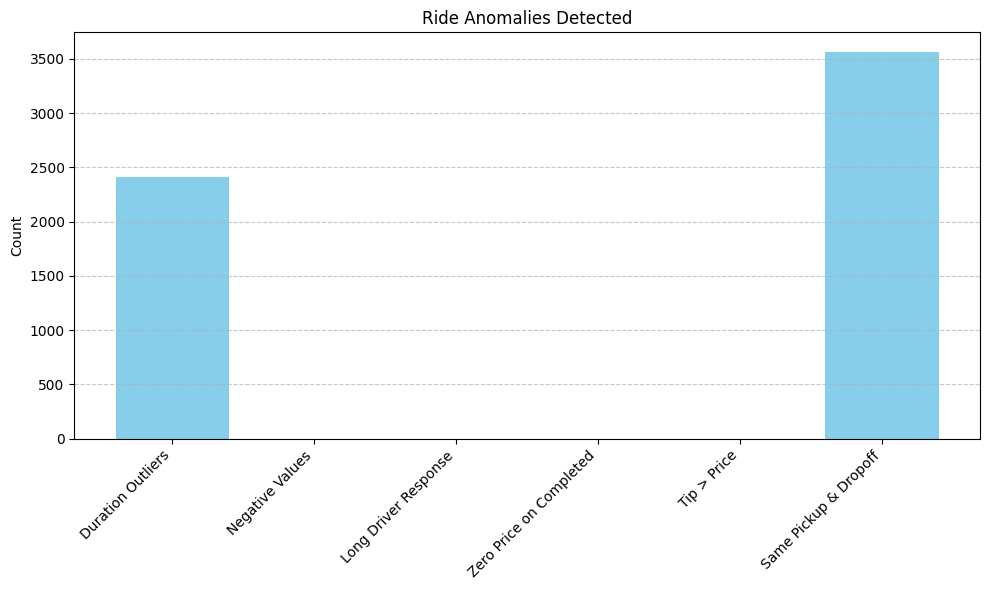

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(anomaly_counts["Anomaly Type"], anomaly_counts["Count"], color="skyblue")
plt.title("Ride Anomalies Detected")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

As we can see, there were many anomalies in terms of duration i.e.: rides that lasted less than a minute or more than 2 hours. However, as we have previously assessed, these correspond with cancelled rides and therefore will not be taken into account.

In terms of real anomalies, there are over 3500 cases that correspond with rides that have the same pick up and drop off points.

In [ ]:
same_location_df = df_rides.filter(col("pickup_location") == col("dropoff_location"))

same_location_df.groupBy("ride_status").count().orderBy("count", ascending=False).show()

+-----------+-----+
|ride_status|count|
+-----------+-----+
|  completed| 3088|
|  cancelled|  477|
+-----------+-----+



Most of these rides were completed, which indicates that possibly these locations were simply within short distances of one another, since they are classified by areas i.e.: university, airport, downtown. These definitely correspond with some of the shortest rides from the whole set of records.